In [1]:
import os

from tabletop_py.gaze.preprocess import preprocess_data
from tabletop_py.gaze.visualization import (
    animate_2d_dots,
    animate_3d_dots,
    plot_eyelink_markers,
)

In [7]:
session_dir = os.path.join(
    os.environ["ROS_BAG_DIR"], "session_2025-08-12_15-19-30"
)

df = preprocess_data(session_dir, save=True)
df.describe()

Matched 8116 (5777 unique) out of 7348 marker data points
After removing duplicates, 5777 out of previous 8116 marker data points remain
Marker time gaps before merging | min: 0.0076, max: 0.0091
Marker time gaps after merging | min: 0.0070, max: 0.8250
Found 1047 rows (forming 68 contiguous gaps) where the time since the last marker datapoint is greater than the maximum expected gap: 0.0091
Dropped 1338 out of 47486 rows


,time,left_x,left_y,right_x,right_y,marker_x,marker_y,marker_z
count,47485.000000,47485.000000,47485.000000,47485.000000,47485.000000,47485.000000,47485.000000,47485.000000
mean,29.370482,-4293.584943,-10448.011856,-4577.603433,-9914.859914,-0.173575,0.192453,0.444806
std,16.471972,2764.834268,2589.606929,2667.950015,2213.142842,0.093107,0.096635,0.088132
min,1.009038,-23123.000000,-27073.000000,-10227.000000,-24979.000000,-0.418199,-0.031162,0.255252
25%,15.749326,-6316.000000,-11838.000000,-6705.000000,-11160.000000,-0.237493,0.112661,0.371865
50%,28.926577,-4337.000000,-10122.000000,-4665.000000,-9718.000000,-0.166400,0.193518,0.435083
75%,42.311897,-2091.000000,-8752.000000,-2505.000000,-8414.000000,-0.113774,0.263686,0.514260
max,61.930384,1527.000000,4900.000000,7861.000000,-4928.000000,0.045189,0.446701,0.655147


In [3]:
df

,time,left_x,left_y,right_x,right_y,marker_x,marker_y,marker_z
0,1.009038,-1223.0,-9812.0,-1529.0,-9759.0,-0.190880,0.174357,0.559456
1,1.009968,-1225.0,-9792.0,-1530.0,-9758.0,-0.190609,0.174540,0.559372
2,1.010964,-1226.0,-9793.0,-1532.0,-9754.0,-0.190318,0.174735,0.559283
3,1.011963,-1226.0,-9794.0,-1551.0,-9750.0,-0.190027,0.174931,0.559194
4,1.012964,-1226.0,-9791.0,-1551.0,-9740.0,-0.189735,0.175127,0.559104
...,...,...,...,...,...,...,...,...
47480,61.926375,-3921.0,-11560.0,-4106.0,-10791.0,-0.130551,0.099763,0.453453
47481,61.927373,-3921.0,-11560.0,-4099.0,-10796.0,-0.130524,0.099696,0.453657
47482,61.928371,-3903.0,-11560.0,-4102.0,-10790.0,-0.130496,0.099630,0.453861
47483,61.929412,-3903.0,-11560.0,-4102.0,-10791.0,-0.130468,0.099560,0.454074


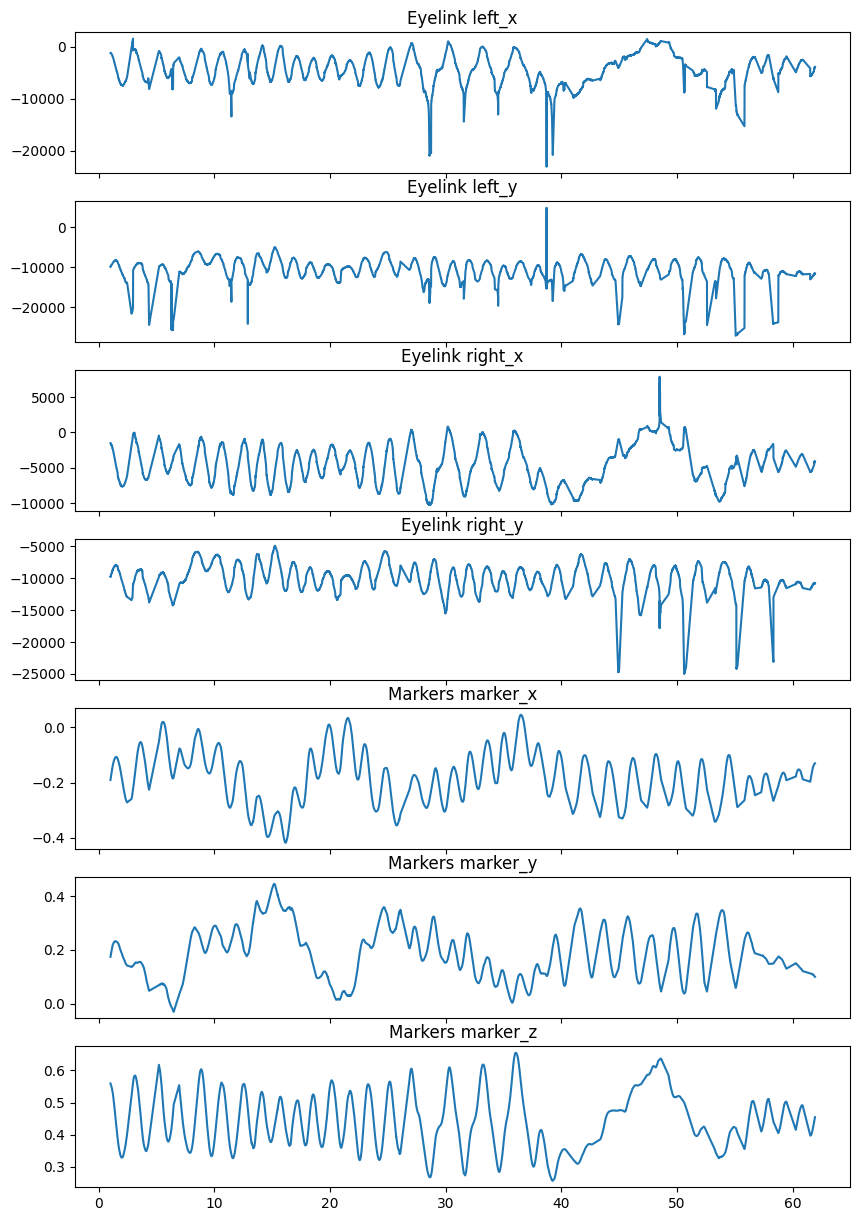

In [4]:
plot_eyelink_markers(df, df)

In [5]:
arr = df[["left_x", "left_y", "right_x", "right_y"]].values
arr = arr.reshape(arr.shape[0], 2, 2)

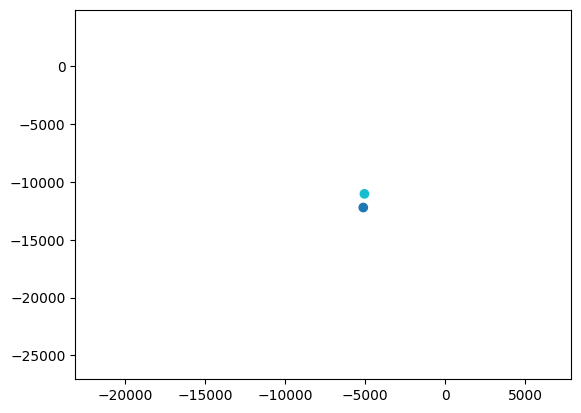

In [6]:
animate_2d_dots(arr, 1000, save_path="eyelink.mp4")

In [5]:
arr = df[["marker_x", "marker_y", "marker_z"]].values
arr = arr.reshape(arr.shape[0], 1, 3)

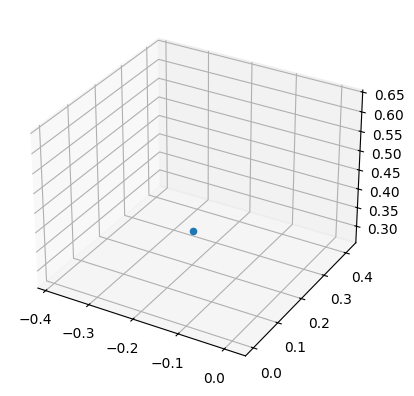

In [6]:
animate_3d_dots(arr, 1000, save_path="markers.mp4")